In [207]:
%run general_functions.ipynb

In [208]:
dic = xr.open_dataset('/Users/chiaraciscato/Desktop/GEOMAR/2024_ciscato_oae_seasonality/lastDecade/DIC_base26_lastDecade.nc')
mld = xr.open_dataset('/Users/chiaraciscato/Desktop/GEOMAR/2024_ciscato_oae_seasonality/lastDecade/mld_base26_lastDecade.nc')
npp = xr.open_dataset('/Users/chiaraciscato/Downloads/wetransfer_npp_2025-06-18_0759/npp_base_26.nc')
# wind = xr.open_dataset('/Volumes/ccHD/OAEdata/variables/wind/base26.nc')

In [209]:
# ns = xr.open_dataset('/Users/chiaraciscato/Desktop/GEOMAR/2024_ciscato_oae_seasonality/north_sea_polygon.nc')

In [210]:
mesh = xr.open_dataset('/Users/chiaraciscato/Desktop/GEOMAR/2024_ciscato_oae_seasonality/lastDecade/mesh_mask.nc')

In [211]:
mesh = mesh.tmask.isel(t=0,z=0)

In [212]:
polygon_coords = [(67, 88), (78, 96), (94, 72), (80, 55), (66,76)]

x = mesh['x'].values
y = mesh['y'].values
mesh = mesh['tmask'].values

X, Y = np.meshgrid(x, y)
points = np.vstack((X.ravel(), Y.ravel())).T

poly_path = Path(polygon_coords)

ns_mask = poly_path.contains_points(points).reshape(X.shape)

mesh_fin = mesh * ns_mask
# mesh_fin = mesh_fin.where(mesh_fin)
# mesh_fin = mesh_fin.to_dataset(name='ns')

KeyError: 'tmask'

In [199]:
mesh_fin

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=int8)

In [197]:
mesh_fin.plot()

AttributeError: 'numpy.ndarray' object has no attribute 'plot'

In [159]:
def depth_mask(data, var, depth):

    data_mask = copy.deepcopy(data)
    data_mask = data_mask * ns_mask

    data_mask = data_mask.where(data_mask)
    # turn not nulls in integers
    data_mask[var] = data_mask[var].notnull().astype(int)
    # sum ones along depth dimension
    mask_sum = data_mask[var].sum(dim=depth).astype(int)
    # zip sums to coordinate values
    depth_levels = xr.DataArray(data[depth].values, dims=[depth], coords={depth: data[depth]})
    mask_depth_values = copy.deepcopy(mask_sum)
    for i, depth_value in enumerate(depth_levels):
        mask_depth_values = mask_depth_values.where(mask_sum != i + 1, depth_value)
    
    mask_ds = mask_depth_values.to_dataset(name='bathymetry')
    mask_ds = mask_ds.where(mask_ds['bathymetry'].notnull())
    mask_ds = mask_ds.where(mask_ds)

    mask_ds = mask_ds.where(mask_ds)

    # mask_ds = mask_ds.where((mask_ds.nav_lon>-3)&(mask_ds.nav_lon<13)&(mask_ds.nav_lat>50)&(mask_ds.nav_lat<60), drop=True).isel(time_counter=0)
    
    return mask_ds

In [160]:
bathymetry = depth_mask(dic, 'DIC', 'deptht')

ValueError: operands could not be broadcast together with shapes (120,46,105,75) (511,722) 

In [ ]:
bathymetry.bathymetry.plot(vmin=0, vmax=250)

In [80]:
def slicing(data, mld, var):
    mld_bool = (data['deptht'] < mld.somxl010).to_dataset(name='mld') 
    data *= mld_bool['mld']
    data = data.where(data).fillna(0)
    layers_sum = [
        data[var].isel(deptht=x) * (data.deptht[x] if x == 0 else (data.deptht[x] - data.deptht[x - 1]))
        for x in range(len(data.deptht))
    ]
    
    weighted_var = (sum(layers_sum) / mld.somxl010).to_dataset(name=var)
    return weighted_var

In [81]:
def monthly_means(data, var):
    data = data.where(data)
    
    if var == 'DIC':
        data = slicing(data, mld, var)

    # north sea coordinates
    # data = data.where((data.nav_lon>-3)&(data.nav_lon<13)&(data.nav_lat>50)&(data.nav_lat<60), drop=True)
    data = data.sel(time_counter=slice('2090','2100'))
    
    m_lenght = data[var].time_counter.dt.days_in_month
    data = (data[var] * m_lenght).groupby("time_counter.month").mean(dim="time_counter") / m_lenght.groupby("time_counter.month").mean(dim="time_counter")
    data = data.to_dataset(name=var)
    
    data = data.mean(dim='x')
    if 'deptht' in data.dims:
        data = data.isel(deptht=0)
    
    return data

In [82]:
def homvoller(data, var, ax):
    im = data[var].T.plot.pcolormesh(
        ax=ax,
        cmap=cmap,
        add_colorbar=False
        )
    return im

In [83]:
dic = monthly_means(dic, 'DIC')
mld = monthly_means(mld, 'somxl010')
npp = monthly_means(npp, 'bgc_diag_pp')

In [84]:
cmap = cm.torch_r

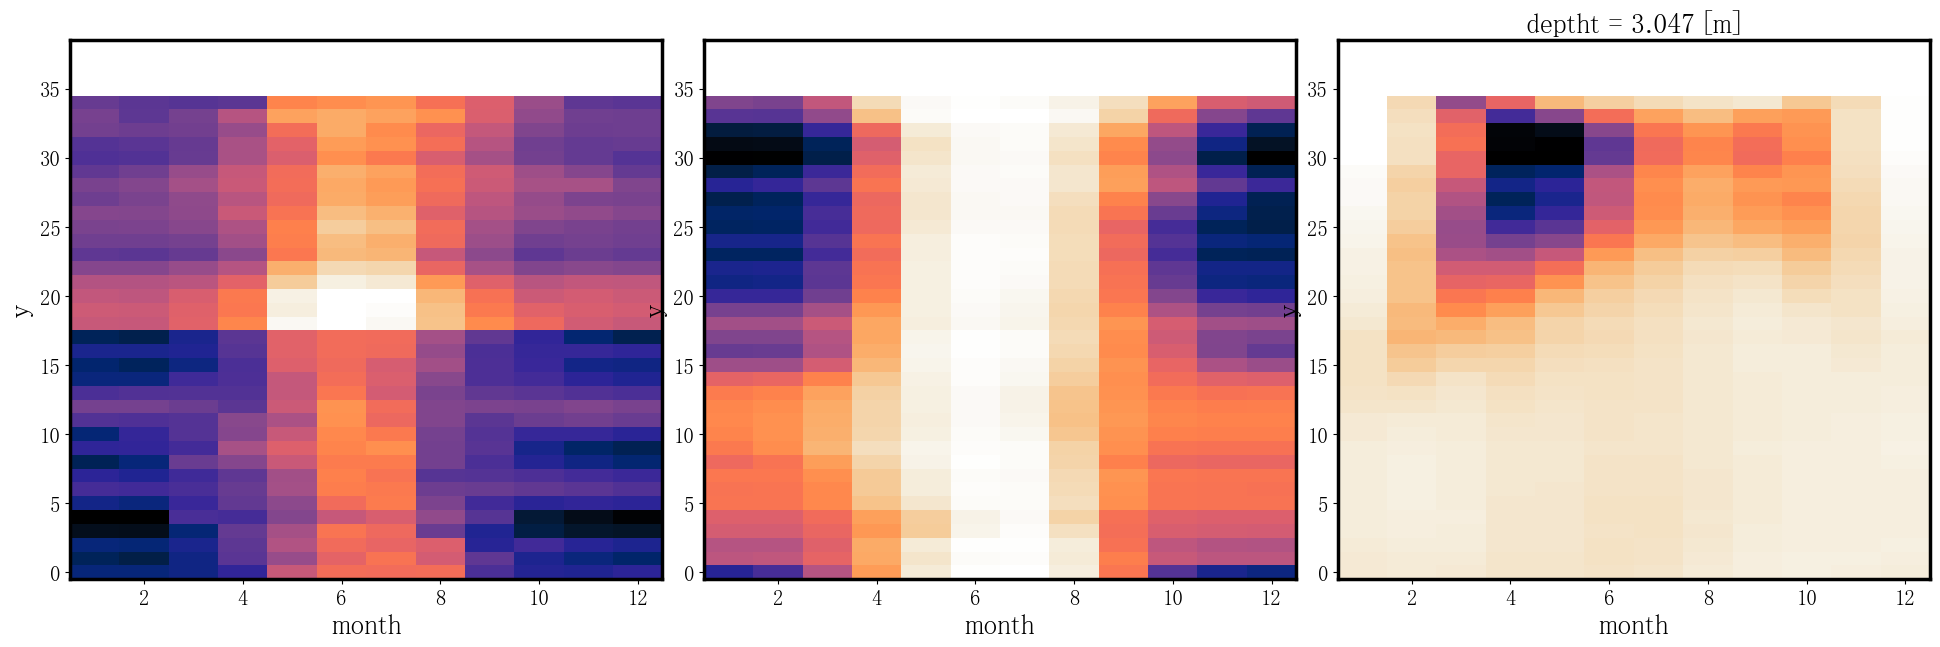

In [85]:
fig, (ax1, ax2, ax3) = plt.subplots(ncols=3, figsize=(24, 7))
plt.subplots_adjust(wspace=0.07)

im_dic = homvoller(dic, 'DIC', ax1)
im_mld = homvoller(mld, 'somxl010', ax2)
im_npp = homvoller(npp, 'bgc_diag_pp', ax3)

# cbar_dic = plt.colorbar(im1, ax=ax1, aspect = 30, pad=0.05, location='top')
# cbar_dic.set_label('DIC [μ mol $\mathregular{kg^{-1}}$]', fontsize=18, labelpad=14)

# cbar_sst = plt.colorbar(im2, ax=ax2, aspect = 30, pad=0.05, location='top')
# cbar_sst.set_label('Mixed layer depth [m]', fontsize=18, labelpad=14)

# cbar_mld = plt.colorbar(im3, ax=ax3, aspect = 30, pad=0.05, location='top')
# cbar_mld.set_label('Sea surface temperature [°C]', fontsize=18, labelpad=14)

# cbar_wind = plt.colorbar(im4, ax=ax4, aspect = 30, pad=0.05, location='top')
# cbar_wind.set_label('Wind speed [m $\mathregular{s^{-1}}$]', fontsize=18, labelpad=14)

# cbars = [cbar_dic, cbar_sst, cbar_mld, cbar_wind]

# axes_no = [ax2, ax3, ax4]

# for ax in axes_no:
#     ax.set(yticklabels=[])
#     ax.set_ylabel('')

# axes = [ax1, ax2, ax3, ax4]

# for ax in axes:
#     x = list(range(1,13))
#     ax.set_xticks(np.arange(min(x), max(x)+1, 1))
#     labels_month = [item.get_text() for item in ax.get_xticklabels()]
#     month_label = ['J', 'F', 'M', 'A', 'M', 'J', 'J', 'A', 'S', 'O', 'N', 'D']
#     ax.set_xticklabels(month_label, fontsize=12)
#     ax.set_xlabel('Month', fontsize=16, labelpad=12)
#     ax.set_title('')
    
# y = list(range(1,48))
# ax1.set_yticks(np.arange(min(y), max(y), 8))
# labels_lat = [item.get_text() for item in ax1.get_yticklabels()]
# lat_label = ['51°N', '53°N', '55°N', '57°N', '59°N', '61°N']
# ax1.set_yticklabels(lat_label, fontsize=14)
# ax1.set_ylabel('Latitude', fontsize=16, labelpad=12)

# for n, ax in enumerate(axes):
#     ax.text(0.88, 0.9, string.punctuation[7] + string.ascii_lowercase[n] + string.punctuation[8],
#             transform=ax.transAxes, size=22, weight='bold', color='white')
    
# for location in ['left','bottom', 'right', 'top']:
#     for ax in axes:
#         ax.spines[location].set_linewidth(0.4)
#     for cbar in cbars: 
#         cbar.ax.set_frame_on(False)
#         cbar.ax.tick_params(labelsize=12)
    
pass

# plt.savefig('/Users/chiaraciscato/Desktop/GEOMAR/OAEseasonality/out/northSea.png')

In [86]:
# fig, (ax1, ax2, ax3, ax4) = plt.subplots(ncols=4, figsize=(24, 7))
# plt.subplots_adjust(wspace=0.07)

# im1 = new_list[0].T.plot.pcolormesh(
#         ax=ax1,
#         cmap=cmap,
#         add_colorbar=False
#         )
# im2 = new_list[1].somxl010.T.plot.pcolormesh(
#         ax=ax2,
#         cmap=cmap,
#         add_colorbar=False
#         )
# im3 = new_list[2].isel(time=0).sst.T.plot.pcolormesh(
#         ax=ax3,
#         cmap=cmap,
#         add_colorbar=False
#         )
# im4 = new_list[3].wind.T.plot.pcolormesh(
#         ax=ax4,
#         cmap=cmap,
#         add_colorbar=False
#         )

# cbar_dic = plt.colorbar(im1, ax=ax1, aspect = 30, pad=0.05, location='top')
# cbar_dic.set_label('DIC [μ mol $\mathregular{kg^{-1}}$]', fontsize=18, labelpad=14)

# cbar_sst = plt.colorbar(im2, ax=ax2, aspect = 30, pad=0.05, location='top')
# cbar_sst.set_label('Mixed layer depth [m]', fontsize=18, labelpad=14)

# cbar_mld = plt.colorbar(im3, ax=ax3, aspect = 30, pad=0.05, location='top')
# cbar_mld.set_label('Sea surface temperature [°C]', fontsize=18, labelpad=14)

# cbar_wind = plt.colorbar(im4, ax=ax4, aspect = 30, pad=0.05, location='top')
# cbar_wind.set_label('Wind speed [m $\mathregular{s^{-1}}$]', fontsize=18, labelpad=14)

# cbars = [cbar_dic, cbar_sst, cbar_mld, cbar_wind]

# axes_no = [ax2, ax3, ax4]

# for ax in axes_no:
#     ax.set(yticklabels=[])
#     ax.set_ylabel('')

# axes = [ax1, ax2, ax3, ax4]

# for ax in axes:
#     x = list(range(1,13))
#     ax.set_xticks(np.arange(min(x), max(x)+1, 1))
#     labels_month = [item.get_text() for item in ax.get_xticklabels()]
#     month_label = ['J', 'F', 'M', 'A', 'M', 'J', 'J', 'A', 'S', 'O', 'N', 'D']
#     ax.set_xticklabels(month_label, fontsize=12)
#     ax.set_xlabel('Month', fontsize=16, labelpad=12)
#     ax.set_title('')
    
# y = list(range(1,48))
# ax1.set_yticks(np.arange(min(y), max(y), 8))
# labels_lat = [item.get_text() for item in ax1.get_yticklabels()]
# lat_label = ['51°N', '53°N', '55°N', '57°N', '59°N', '61°N']
# ax1.set_yticklabels(lat_label, fontsize=14)
# ax1.set_ylabel('Latitude', fontsize=16, labelpad=12)

# for n, ax in enumerate(axes):
#     ax.text(0.88, 0.9, string.punctuation[7] + string.ascii_lowercase[n] + string.punctuation[8],
#             transform=ax.transAxes, size=22, weight='bold', color='white')
    
# for location in ['left','bottom', 'right', 'top']:
#     for ax in axes:
#         ax.spines[location].set_linewidth(0.4)
#     for cbar in cbars: 
#         cbar.ax.set_frame_on(False)
#         cbar.ax.tick_params(labelsize=12)
    
# pass

# # plt.savefig('/Users/chiaraciscato/Desktop/GEOMAR/OAEseasonality/out/northSea.png')